# Milestone 0 - Data Preparation and EDA

Dataset: Amazon Reviews 2023 from Hugging Face. Selected category: `All_Beauty`.

This notebook satisfies Milestone 0:
- choose one product category;
- load reviews and product metadata;
- clean and join review + metadata records;
- construct review-level and product-level tables;
- split by product, not by review, to avoid leakage;
- cache a configurable sample of product images;
- run EDA for ratings, prices, review length, image availability, and missing data;
- save frozen train/validation/test review-level splits.


## 0. Setup

`MAX_IMAGES_TO_CACHE` defaults to 300 for fast, reproducible EDA notebook runs. The full Computer Vision milestone target is kept separately as `FULL_IMAGE_CACHE_TARGET = 5000`, and the same downloader can be run later with `MAX_IMAGES_TO_CACHE=5000`.


In [1]:
from __future__ import annotations

import hashlib
import os
import re
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGE_CACHE_DIR = DATA_DIR / "images" / "all_beauty"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

HF_DATASET = "McAuley-Lab/Amazon-Reviews-2023"
CATEGORY = "All_Beauty"
REVIEWS_CONFIG = f"raw_review_{CATEGORY}"
META_CONFIG = f"raw_meta_{CATEGORY}"

MAX_REVIEW_SAMPLE = 50_000
RANDOM_STATE = 42
MAX_IMAGES_TO_CACHE = int(os.getenv("MAX_IMAGES_TO_CACHE", "300"))
FULL_IMAGE_CACHE_TARGET = 5000
IMAGE_DOWNLOAD_TIMEOUT = 15

REVIEWS_CACHE_PATH = PROCESSED_DIR / "all_beauty_reviews_sample.parquet"
METADATA_CACHE_PATH = PROCESSED_DIR / "all_beauty_meta_sample.parquet"
IMAGE_MANIFEST_PATH = PROCESSED_DIR / "all_beauty_image_manifest.csv"
MISSING_REPORT_PATH = PROCESSED_DIR / "missing_data_report.csv"
REVIEW_LEVEL_PATH = PROCESSED_DIR / "review_level.parquet"
PRODUCT_LEVEL_PATH = PROCESSED_DIR / "product_level.parquet"
MERGED_SAMPLE_PATH = PROCESSED_DIR / "all_beauty_merged_sample.parquet"
TRAIN_PATH = PROCESSED_DIR / "train.parquet"
VAL_PATH = PROCESSED_DIR / "val.parquet"
VALIDATION_ALIAS_PATH = PROCESSED_DIR / "validation.parquet"
TEST_PATH = PROCESSED_DIR / "test.parquet"
BASELINE_METRICS_PATH = PROCESSED_DIR / "baseline_majority_sentiment_metrics.csv"

print(f"Selected category: {CATEGORY}")
print(f"Current quick-run image cache limit: {MAX_IMAGES_TO_CACHE:,}")
print(f"Full Computer Vision milestone cache target: {FULL_IMAGE_CACHE_TARGET:,}")


Selected category: All_Beauty
Current quick-run image cache limit: 300
Full Computer Vision milestone cache target: 5,000


## 1. Helper Functions

The notebook is self-contained so it can run in VSCode/Jupyter without relying on external project modules.


In [3]:
TEXT_COLUMN_CANDIDATES = ["text", "review_text", "reviewText"]
RATING_COLUMN_CANDIDATES = ["rating", "overall"]
TIME_COLUMN_CANDIDATES = ["timestamp", "unixReviewTime", "time"]
PRODUCT_ID_CANDIDATES = ["parent_asin", "asin"]
USER_ID_CANDIDATES = ["user_id", "reviewerID"]
TITLE_COLUMN_CANDIDATES = ["title", "product_title"]
PRICE_COLUMN_CANDIDATES = ["price"]
STORE_COLUMN_CANDIDATES = ["store"]
MAIN_CATEGORY_CANDIDATES = ["main_category"]
IMAGE_URL_PRIORITIES = ["hi_res", "large", "thumb"]
MANIFEST_COLUMNS = [
    "product_id",
    "primary_image_url",
    "cached_image_path",
    "image_cache_status",
    "image_cache_error",
]


def first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for column in candidates:
        if column in df.columns:
            return column
    return None


def clean_text(value: object) -> str:
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_price(value: object) -> float | pd.NA:
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if text == "" or text.lower() in {"none", "nan"}:
        return pd.NA
    matches = re.findall(r"\d+(?:\.\d+)?", text.replace(",", ""))
    if not matches:
        return pd.NA
    return float(matches[0])


def extract_primary_image_url(images: object) -> str | None:
    if not isinstance(images, dict):
        return None
    for key in IMAGE_URL_PRIORITIES:
        values = images.get(key)
        if not hasattr(values, "__iter__") or isinstance(values, (str, bytes)):
            continue
        for value in values:
            if isinstance(value, str) and value.startswith("http"):
                return value
    return None


def image_filename(product_id: object, url: str) -> str:
    parsed_path = urlparse(url).path
    suffix = Path(parsed_path).suffix
    if not suffix or len(suffix) > 8:
        suffix = ".jpg"
    digest = hashlib.md5(url.encode("utf-8")).hexdigest()[:10]
    safe_product_id = str(product_id).replace("/", "_")
    return f"{safe_product_id}_{digest}{suffix}"


def to_relative_path(path_value: object, project_root: Path = PROJECT_ROOT) -> str:
    if pd.isna(path_value) or str(path_value).strip() == "":
        return ""
    path = Path(str(path_value))
    if path.is_absolute():
        try:
            return str(path.relative_to(project_root))
        except ValueError:
            return str(path)
    return str(path)


def path_exists(path_value: object, project_root: Path = PROJECT_ROOT) -> bool:
    rel_path = to_relative_path(path_value, project_root)
    if rel_path == "":
        return False
    path = Path(rel_path)
    if not path.is_absolute():
        path = project_root / path
    return path.exists() and path.is_file()


In [4]:
def load_hf_split(config_name: str, split: str = "full"):
    return load_dataset(
        HF_DATASET,
        config_name,
        split=split,
        trust_remote_code=True,
    )


def load_or_create_reviews_cache(path: Path, sample_size: int = MAX_REVIEW_SAMPLE) -> pd.DataFrame:
    if path.exists():
        return pd.read_parquet(path)
    df = load_hf_split(REVIEWS_CONFIG).to_pandas()
    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=RANDOM_STATE)
    df = df.reset_index(drop=True)
    df.to_parquet(path, index=False)
    return df


def load_or_create_metadata_cache(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_parquet(path)
    df = load_hf_split(META_CONFIG).to_pandas().reset_index(drop=True)
    df.to_parquet(path, index=False)
    return df


In [5]:
def prepare_reviews(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    text_col = first_existing_column(out, TEXT_COLUMN_CANDIDATES)
    rating_col = first_existing_column(out, RATING_COLUMN_CANDIDATES)
    time_col = first_existing_column(out, TIME_COLUMN_CANDIDATES)
    product_col = first_existing_column(out, PRODUCT_ID_CANDIDATES)
    user_col = first_existing_column(out, USER_ID_CANDIDATES)

    out["review_text"] = out[text_col].fillna("").astype(str) if text_col else ""
    out["clean_review_text"] = out["review_text"].map(clean_text)
    out["review_length"] = out["clean_review_text"].str.split().str.len()

    if rating_col:
        out["rating_num"] = pd.to_numeric(out[rating_col], errors="coerce")
        out["sentiment_label"] = pd.cut(
            out["rating_num"],
            bins=[0, 2, 3, 5],
            labels=["negative", "neutral", "positive"],
            include_lowest=True,
        )

    if time_col:
        numeric_time = pd.to_numeric(out[time_col], errors="coerce")
        unit = "ms" if numeric_time.dropna().gt(10_000_000_000).any() else "s"
        out["review_date"] = pd.to_datetime(numeric_time, unit=unit, errors="coerce")
        out["review_year"] = out["review_date"].dt.year
        out["review_month"] = out["review_date"].dt.to_period("M").astype(str)

    if product_col and product_col != "product_id":
        out["product_id"] = out[product_col]
    if user_col and user_col != "user_id":
        out["user_id"] = out[user_col]
    if "verified_purchase" in out.columns:
        out["verified_purchase"] = out["verified_purchase"].fillna(False).astype(bool)

    return out


def prepare_metadata(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    product_col = first_existing_column(out, PRODUCT_ID_CANDIDATES)
    title_col = first_existing_column(out, TITLE_COLUMN_CANDIDATES)
    price_col = first_existing_column(out, PRICE_COLUMN_CANDIDATES)
    store_col = first_existing_column(out, STORE_COLUMN_CANDIDATES)
    main_category_col = first_existing_column(out, MAIN_CATEGORY_CANDIDATES)

    if product_col and product_col != "product_id":
        out["product_id"] = out[product_col]
    if title_col:
        out["product_title"] = out[title_col].fillna("").astype(str)
    if price_col:
        out["price_num"] = out[price_col].map(clean_price).pipe(pd.to_numeric, errors="coerce")
    elif "price_num" not in out.columns:
        out["price_num"] = pd.NA
    if store_col:
        out["store_name"] = out[store_col].fillna("").astype(str)
    if main_category_col:
        out["main_category_clean"] = out[main_category_col].fillna("").astype(str)
    if "images" in out.columns:
        out["primary_image_url"] = out["images"].map(extract_primary_image_url)
    if "product_id" in out.columns:
        out = out.drop_duplicates(subset=["product_id"])
    return out


In [6]:
def load_existing_image_manifest(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=MANIFEST_COLUMNS)
    manifest = pd.read_csv(path)
    for column in MANIFEST_COLUMNS:
        if column not in manifest.columns:
            manifest[column] = pd.NA
    manifest = manifest[MANIFEST_COLUMNS].copy()
    manifest["product_id"] = manifest["product_id"].astype(str)
    manifest["cached_image_path"] = manifest["cached_image_path"].fillna("").map(to_relative_path)
    manifest.loc[~manifest["cached_image_path"].map(path_exists), "image_cache_status"] = "missing_file"
    manifest.loc[~manifest["cached_image_path"].map(path_exists), "cached_image_path"] = ""
    return manifest.drop_duplicates("product_id", keep="last")


def cache_product_images(
    metadata: pd.DataFrame,
    cache_dir: Path,
    manifest_path: Path,
    max_images: int = MAX_IMAGES_TO_CACHE,
    timeout: int = IMAGE_DOWNLOAD_TIMEOUT,
) -> pd.DataFrame:
    if "product_id" not in metadata.columns:
        raise ValueError("metadata must contain product_id before caching images.")
    if "primary_image_url" not in metadata.columns:
        raise ValueError("metadata must contain primary_image_url before caching images.")

    cache_dir.mkdir(parents=True, exist_ok=True)
    manifest_path.parent.mkdir(parents=True, exist_ok=True)

    manifest = load_existing_image_manifest(manifest_path)
    manifest_by_product = {str(row.product_id): row for row in manifest.itertuples(index=False)}

    candidates = (
        metadata[["product_id", "primary_image_url"]]
        .dropna(subset=["primary_image_url"])
        .drop_duplicates("product_id")
        .head(max_images)
    )

    rows_by_product = {str(row.product_id): row._asdict() for row in manifest.itertuples(index=False)}

    for row in candidates.itertuples(index=False):
        product_id = str(row.product_id)
        url = row.primary_image_url
        existing = manifest_by_product.get(product_id)

        if existing is not None and existing.image_cache_status == "cached" and path_exists(existing.cached_image_path):
            rows_by_product[product_id] = {
                "product_id": product_id,
                "primary_image_url": existing.primary_image_url,
                "cached_image_path": to_relative_path(existing.cached_image_path),
                "image_cache_status": "cached",
                "image_cache_error": "",
            }
            continue

        local_rel_path = Path("data") / "images" / "all_beauty" / image_filename(product_id, url)
        local_abs_path = PROJECT_ROOT / local_rel_path

        if local_abs_path.exists():
            rows_by_product[product_id] = {
                "product_id": product_id,
                "primary_image_url": url,
                "cached_image_path": str(local_rel_path),
                "image_cache_status": "cached",
                "image_cache_error": "",
            }
            continue

        try:
            response = requests.get(url, timeout=timeout)
            response.raise_for_status()
            local_abs_path.write_bytes(response.content)
            status = "cached"
            error = ""
            cached_path = str(local_rel_path)
        except Exception as exc:
            status = "failed"
            error = str(exc)[:250]
            cached_path = ""

        rows_by_product[product_id] = {
            "product_id": product_id,
            "primary_image_url": url,
            "cached_image_path": cached_path,
            "image_cache_status": status,
            "image_cache_error": error,
        }

    out = pd.DataFrame(rows_by_product.values(), columns=MANIFEST_COLUMNS)
    out = out.drop_duplicates("product_id", keep="last") if not out.empty else pd.DataFrame(columns=MANIFEST_COLUMNS)
    out.to_csv(manifest_path, index=False)
    return out


def attach_cached_image_paths(metadata: pd.DataFrame, manifest: pd.DataFrame) -> pd.DataFrame:
    out = metadata.copy()
    if manifest.empty:
        out["cached_image_path"] = ""
        out["image_cache_status"] = pd.NA
        return out
    manifest_subset = manifest[["product_id", "cached_image_path", "image_cache_status"]].copy()
    return out.merge(manifest_subset, on="product_id", how="left")


In [7]:
def merge_reviews_metadata(reviews: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    metadata_columns = [
        column
        for column in [
            "product_id",
            "product_title",
            "store_name",
            "price_num",
            "main_category_clean",
            "categories",
            "details",
            "average_rating",
            "rating_number",
            "primary_image_url",
            "cached_image_path",
            "image_cache_status",
        ]
        if column in metadata.columns
    ]
    return reviews.merge(metadata[metadata_columns], on="product_id", how="left", validate="many_to_one")


def build_missing_data_report(df: pd.DataFrame, columns: list[str], output_path: Path) -> pd.DataFrame:
    rows = []
    for column in columns:
        if column not in df.columns:
            continue
        series = df[column]
        missing_mask = series.isna()
        if pd.api.types.is_string_dtype(series) or series.dtype == "object":
            missing_mask = missing_mask | series.astype(str).str.strip().isin(["", "nan", "None"])
        rows.append({
            "column": column,
            "missing_count": int(missing_mask.sum()),
            "missing_pct": round(float(missing_mask.mean() * 100), 2),
        })
    report = pd.DataFrame(rows).sort_values("missing_pct", ascending=False)
    report.to_csv(output_path, index=False)
    return report


def build_product_level_table(review_level: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    review_agg = (
        review_level.groupby("product_id")
        .agg(
            review_count=("rating_num", "size"),
            review_rating_mean=("rating_num", "mean"),
            review_rating_median=("rating_num", "median"),
            negative_review_count=("sentiment_label", lambda s: (s.astype(str) == "negative").sum()),
            positive_review_count=("sentiment_label", lambda s: (s.astype(str) == "positive").sum()),
        )
        .reset_index()
    )

    metadata_cols = [
        column
        for column in [
            "product_id",
            "product_title",
            "store_name",
            "price_num",
            "average_rating",
            "rating_number",
            "primary_image_url",
            "cached_image_path",
            "image_cache_status",
            "main_category_clean",
        ]
        if column in metadata.columns
    ]

    product_level = metadata[metadata_cols].drop_duplicates("product_id").merge(review_agg, on="product_id", how="left")
    product_level["review_count"] = product_level["review_count"].fillna(0).astype(int)
    product_level["negative_review_count"] = product_level["negative_review_count"].fillna(0).astype(int)
    product_level["positive_review_count"] = product_level["positive_review_count"].fillna(0).astype(int)
    return product_level


def create_product_split(df: pd.DataFrame, product_col: str = "product_id") -> pd.DataFrame:
    out = df.dropna(subset=[product_col]).copy()
    products = pd.Series(out[product_col].dropna().unique(), name=product_col)

    train_products, temp_products = train_test_split(
        products,
        train_size=0.70,
        random_state=RANDOM_STATE,
        shuffle=True,
    )
    val_products, test_products = train_test_split(
        temp_products,
        train_size=0.50,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    split_map = {product_id: "train" for product_id in train_products}
    split_map.update({product_id: "val" for product_id in val_products})
    split_map.update({product_id: "test" for product_id in test_products})

    out["split"] = out[product_col].map(split_map)
    return out


def product_overlap_report(split_df: pd.DataFrame) -> dict[str, int]:
    train_ids = set(split_df.loc[split_df["split"] == "train", "product_id"])
    val_ids = set(split_df.loc[split_df["split"] == "val", "product_id"])
    test_ids = set(split_df.loc[split_df["split"] == "test", "product_id"])
    return {
        "train_val_overlap": len(train_ids & val_ids),
        "train_test_overlap": len(train_ids & test_ids),
        "val_test_overlap": len(val_ids & test_ids),
    }


## 2. Load Reviews and Metadata

The first run downloads from Hugging Face. Later runs use local parquet caches in `data/processed/`.


In [8]:
raw_reviews = load_or_create_reviews_cache(REVIEWS_CACHE_PATH, sample_size=MAX_REVIEW_SAMPLE)
raw_metadata = load_or_create_metadata_cache(METADATA_CACHE_PATH)

print("Raw reviews shape:", raw_reviews.shape)
print("Raw metadata shape:", raw_metadata.shape)
display(raw_reviews.head(3))
display(raw_metadata.head(3))


Raw reviews shape: (50000, 10)
Raw metadata shape: (112590, 16)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Neon pink.,"Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me....","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71oOdSDU5bL._SL256_.jpg', 'medium_image_url':...",B00JQRPB9I,B00JQRPB9I,AFH5GZTYBKKGZ7SB45FUFLNWMUFQ,1431209081000,4,True
1,5.0,Godd experience,Great product. It came when expected.,[],B00QHB48M2,B00QHB48M2,AFGLKF5GMQ3CYUBB2KFCODKBOEYA,1496279099000,0,True
2,5.0,Love This..made my mom's day,My 90 year old mother's favorite fragrance.,[],B01IAFGDYS,B01IAFGDYS,AFTDHU6IXXYGCEJ6JUAI7LFD3JMA,1561392844340,0,True


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'], 'large': ['https://m.media-amazon...","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; 2.38 Pounds"", ""UPC"": ""617390882781""}",B01CUPMQZE,NaN,NaN,NaN
1,All Beauty,"Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Bil...",4.5,3,[],[],None,"{'hi_res': ['https://m.media-amazon.com/images/I/71g1lP0pMbL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/81O...","{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Prone"", ""Brand"": ""Yes To"", ""Age Range (Description)"": ""Adult"", ""Unit Coun...",B076WQZGPM,NaN,NaN,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg', 'https://m.media-amazon.co...","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,NaN,NaN,NaN


## 3. Clean Reviews and Metadata

Key fields are normalized into stable columns such as `product_id`, `review_text`, `rating_num`, `price_num`, and `primary_image_url`.


In [9]:
reviews = prepare_reviews(raw_reviews)
metadata = prepare_metadata(raw_metadata)

print("Clean reviews shape:", reviews.shape)
print("Clean metadata shape:", metadata.shape)
display(reviews.head(3))
display(metadata[[c for c in ["product_id", "product_title", "store_name", "price_num", "primary_image_url"] if c in metadata.columns]].head(3))


Clean reviews shape: (50000, 19)
Clean metadata shape: (112590, 22)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_text,clean_review_text,review_length,rating_num,sentiment_label,review_date,review_year,review_month,product_id
0,5.0,Neon pink.,"Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me....","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71oOdSDU5bL._SL256_.jpg', 'medium_image_url':...",B00JQRPB9I,B00JQRPB9I,AFH5GZTYBKKGZ7SB45FUFLNWMUFQ,1431209081000,4,True,"Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me....",nice formula smooth application with no pooling or shink back i used three coats which is pretty standard for me i m...,51,5.0,positive,2015-05-09 22:04:41.000,2015,2015-05,B00JQRPB9I
1,5.0,Godd experience,Great product. It came when expected.,[],B00QHB48M2,B00QHB48M2,AFGLKF5GMQ3CYUBB2KFCODKBOEYA,1496279099000,0,True,Great product. It came when expected.,great product it came when expected,6,5.0,positive,2017-06-01 01:04:59.000,2017,2017-06,B00QHB48M2
2,5.0,Love This..made my mom's day,My 90 year old mother's favorite fragrance.,[],B01IAFGDYS,B01IAFGDYS,AFTDHU6IXXYGCEJ6JUAI7LFD3JMA,1561392844340,0,True,My 90 year old mother's favorite fragrance.,my 90 year old mother s favorite fragrance,8,5.0,positive,2019-06-24 16:14:04.340,2019,2019-06,B01IAFGDYS


,product_id,product_title,store_name,price_num,primary_image_url
0,B01CUPMQZE,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",Howard Products,NaN,https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg
1,B076WQZGPM,"Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Bil...",Yes To,NaN,https://m.media-amazon.com/images/I/71g1lP0pMbL._SL1500_.jpg
2,B000B658RI,Eye Patch Black Adult with Tie Band (6 Per Pack),Levine Health Products,NaN,https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg


## 4. Cache Product Images

Broken image-link pitfall avoided: images are downloaded during Milestone 0 and later stages should use `cached_image_path`, not live URLs. Normal notebook execution uses a small sample so reruns stay fast; the same code supports a larger CV cache through the environment variable.


### Image Caching Note

For reproducibility and faster notebook execution, this Milestone 0 notebook uses a small default image cache sample. The downloader is configurable through `MAX_IMAGES_TO_CACHE`. For quick EDA runs, we use 300 images. For the Computer Vision milestone, the same pipeline can be run with `MAX_IMAGES_TO_CACHE=5000` to build the larger training image cache recommended in the project brief.


In [10]:
image_manifest = cache_product_images(
    metadata,
    cache_dir=IMAGE_CACHE_DIR,
    manifest_path=IMAGE_MANIFEST_PATH,
    max_images=MAX_IMAGES_TO_CACHE,
    timeout=IMAGE_DOWNLOAD_TIMEOUT,
)
metadata = attach_cached_image_paths(metadata, image_manifest)

image_download_attempts = min(MAX_IMAGES_TO_CACHE, int(metadata["primary_image_url"].notna().sum()))
successful_cached_images = int((image_manifest["image_cache_status"] == "cached").sum()) if "image_cache_status" in image_manifest else 0

image_availability_summary = pd.DataFrame({
    "metric": [
        "metadata_products",
        "products_with_image_url",
        "products_in_image_manifest",
        "attempted_image_downloads_or_cache_checks",
        "successfully_cached_images",
    ],
    "count": [
        len(metadata),
        int(metadata["primary_image_url"].notna().sum()),
        len(image_manifest),
        image_download_attempts,
        successful_cached_images,
    ],
})
image_availability_summary["pct_of_metadata_products"] = (image_availability_summary["count"] / len(metadata) * 100).round(2)

display(image_availability_summary)
display(image_manifest["image_cache_status"].value_counts(dropna=False).rename_axis("status").reset_index(name="products"))
display(image_manifest.head())


,metric,count,pct_of_metadata_products
0,metadata_products,112590,100.00
1,products_with_image_url,112590,100.00
2,products_in_image_manifest,300,0.27
3,attempted_image_downloads_or_cache_checks,300,0.27
4,successfully_cached_images,300,0.27


,status,products
0,cached,300


,product_id,primary_image_url,cached_image_path,image_cache_status,image_cache_error
0,B01CUPMQZE,https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg,data/images/all_beauty/B01CUPMQZE_95d904a0ec.jpg,cached,
1,B076WQZGPM,https://m.media-amazon.com/images/I/71g1lP0pMbL._SL1500_.jpg,data/images/all_beauty/B076WQZGPM_7d12f1725f.jpg,cached,
2,B000B658RI,https://m.media-amazon.com/images/I/31bz+uqzWCL.jpg,data/images/all_beauty/B000B658RI_aedf13be21.jpg,cached,
3,B088FKY3VD,https://m.media-amazon.com/images/I/71GJhXQGvyL._SL1500_.jpg,data/images/all_beauty/B088FKY3VD_de33cbc7ba.jpg,cached,
4,B07NGFDN6G,https://m.media-amazon.com/images/I/31TgqAZ8kQL.jpg,data/images/all_beauty/B07NGFDN6G_3902d8ec67.jpg,cached,


## 5. Join Review-Level Data

This is the main review-level table: one row per review enriched with product metadata and cached image paths.


In [11]:
review_level = merge_reviews_metadata(reviews, metadata)
review_level.to_parquet(REVIEW_LEVEL_PATH, index=False)
review_level.to_parquet(MERGED_SAMPLE_PATH, index=False)

print("Review-level table shape:", review_level.shape)
print("Saved:", REVIEW_LEVEL_PATH.relative_to(PROJECT_ROOT))
display(review_level.head(3))


Review-level table shape: (50000, 30)
Saved: data/processed/review_level.parquet


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_text,clean_review_text,review_length,rating_num,sentiment_label,review_date,review_year,review_month,product_id,product_title,store_name,price_num,main_category_clean,categories,details,average_rating,rating_number,primary_image_url,cached_image_path,image_cache_status
0,5.0,Neon pink.,"Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me....","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71oOdSDU5bL._SL256_.jpg', 'medium_image_url':...",B00JQRPB9I,B00JQRPB9I,AFH5GZTYBKKGZ7SB45FUFLNWMUFQ,1431209081000,4,True,"Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me....",nice formula smooth application with no pooling or shink back i used three coats which is pretty standard for me i m...,51,5.0,positive,2015-05-09 22:04:41.000,2015,2015-05,B00JQRPB9I,"Gelaze Gel-N-Base Polish, Shocking Pink, 0.5 Fluid Ounce",China Glaze,16.45,All Beauty,[],"{""Brand"": ""China Glaze"", ""Item Form"": ""Gel"", ""Color"": ""Nipple-108"", ""Finish Type"": ""Glossy"", ""Age Range (Description...",4.0,18,https://m.media-amazon.com/images/I/51Vjg3wJvqL._SL1000_.jpg,NaN,NaN
1,5.0,Godd experience,Great product. It came when expected.,[],B00QHB48M2,B00QHB48M2,AFGLKF5GMQ3CYUBB2KFCODKBOEYA,1496279099000,0,True,Great product. It came when expected.,great product it came when expected,6,5.0,positive,2017-06-01 01:04:59.000,2017,2017-06,B00QHB48M2,Max Factor Panstik Foundation - 12 True Beige (6 Pack),Max Factor,NaN,All Beauty,[],"{""Item Form"": ""Stick"", ""Color"": ""Beige"", ""Package Information"": ""Bottle"", ""Brand"": ""Max Factor"", ""Age Range (Descrip...",4.8,325,https://m.media-amazon.com/images/I/51XpyI-Zu-L._SL1000_.jpg,NaN,NaN
2,5.0,Love This..made my mom's day,My 90 year old mother's favorite fragrance.,[],B01IAFGDYS,B01IAFGDYS,AFTDHU6IXXYGCEJ6JUAI7LFD3JMA,1561392844340,0,True,My 90 year old mother's favorite fragrance.,my 90 year old mother s favorite fragrance,8,5.0,positive,2019-06-24 16:14:04.340,2019,2019-06,B01IAFGDYS,Five Star Royal Secret Eau De Toilette Spray 1.70 oz (Pack of 2),Five Star,NaN,All Beauty,[],"{""Brand"": ""Five Star"", ""Item Form"": ""Spray"", ""Item Volume"": ""1.7 Fluid Ounces"", ""Fragrance Concentration"": ""eau_de_t...",4.3,7,https://m.media-amazon.com/images/I/71bmIS0CR8L._SL1500_.jpg,NaN,NaN


## 6. Missing-Data Report

The report only includes columns that exist in the joined data and is saved for later documentation.


In [12]:
important_missing_columns = [
    "rating_num",
    "review_text",
    "product_title",
    "price_num",
    "store_name",
    "primary_image_url",
    "cached_image_path",
    "average_rating",
    "rating_number",
]

missing_data_report = build_missing_data_report(review_level, important_missing_columns, MISSING_REPORT_PATH)
print("Saved missing-data report:", MISSING_REPORT_PATH.relative_to(PROJECT_ROOT))
display(missing_data_report)


Saved missing-data report: data/processed/missing_data_report.csv


,column,missing_count,missing_pct
6,cached_image_path,49783,99.57
3,price_num,36782,73.56
4,store_name,3565,7.13
1,review_text,54,0.11
0,rating_num,0,0.00
2,product_title,2,0.00
5,primary_image_url,0,0.00
7,average_rating,0,0.00
8,rating_number,0,0.00


## 7. Product-Level Table

One row per product, combining metadata with review-level aggregates.


In [13]:
product_level = build_product_level_table(review_level, metadata)
product_level.to_parquet(PRODUCT_LEVEL_PATH, index=False)

print("Product-level table shape:", product_level.shape)
print("Saved:", PRODUCT_LEVEL_PATH.relative_to(PROJECT_ROOT))
display(product_level.sort_values("review_count", ascending=False).head(10))


Product-level table shape: (112590, 15)
Saved: data/processed/product_level.parquet


,product_id,product_title,store_name,price_num,average_rating,rating_number,primary_image_url,cached_image_path,image_cache_status,main_category_clean,review_count,review_rating_mean,review_rating_median,negative_review_count,positive_review_count
29627,B0BM4GX6TT,"Godefroy Tint Kit for Spot Coloring, Dark Brown",Godefroy,24.95,4.4,8691,https://m.media-amazon.com/images/I/619lnI6SmSL._SL1500_.jpg,NaN,NaN,All Beauty,147,4.299320,5.0,18,120
33172,B085BB7B1M,Salux Nylon Japanese Beauty Skin Bath Wash Cloth/towel (3) Blue Yellow and Pink,SALUX,12.99,4.7,9101,https://m.media-amazon.com/images/I/91zEaac4rvL._SL1500_.jpg,NaN,NaN,All Beauty,120,4.441667,5.0,12,103
55464,B07C533XCW,Segbeauty empty bottle 160083,Segbeauty,NaN,4.7,11918,https://m.media-amazon.com/images/I/41pC0E7HXUL._SL1500_.jpg,NaN,NaN,All Beauty,106,4.613208,5.0,6,95
26020,B00R1TAN7I,GranNaturals Boar Bristle Smoothing Hair Brush for Women and Men - Medium/Soft Bristles - Natural Wooden Large Flat ...,GranNaturals,12.99,3.9,4199,https://m.media-amazon.com/images/I/81-W7lZQcWL._SL1500_.jpg,NaN,NaN,All Beauty,101,3.881188,5.0,21,69
50620,B019GBG0IE,Collapsible Hair Diffuser by The Curly Co. with The Curly Co. Satisfaction Guarantee,The Curly Co.,16.99,4.1,5312,https://m.media-amazon.com/images/I/718a2f+Y1cL._SL1500_.jpg,NaN,NaN,All Beauty,101,3.564356,4.0,32,58
41982,B08L5KN7X4,Meeteasy Dental Cleaner Tool Kit - Dental Care for Adult - 100% Proven Safe,Meeteasy,24.97,3.9,7944,https://m.media-amazon.com/images/I/71Yil5IFDfL._SL1500_.jpg,NaN,NaN,All Beauty,100,4.020000,5.0,20,74
4626,B09X9BG4FC,Makone Crystal Crowns and Tiaras with Comb Headband for Girl or Women Birthday Party Wedding Prom Bridal Christmas V...,Makone,9.99,4.6,9880,https://m.media-amazon.com/images/I/71a9cu6P5uL._SL1500_.jpg,NaN,NaN,All Beauty,91,4.615385,5.0,6,82
76221,B01M1OFZOG,"Bed Head Curve Check Curling Wand for Tousled Waves and Texture, Jumbo Barrel",Bed Head,27.99,4.3,8144,https://m.media-amazon.com/images/I/51Zm5SXRi2L._AC_SL1000_.jpg,NaN,NaN,All Beauty,90,4.277778,5.0,11,70
43591,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red Bow Headband,Picoway,15.99,4.8,11485,https://m.media-amazon.com/images/I/71v8-FmEMEL._SL1500_.jpg,NaN,NaN,All Beauty,81,4.740741,5.0,3,76
54289,B0107QYW14,Harlorki Women's Bohemian Jewelry Statement Necklaces Women Rhinestone Gem Pendant Collar,Harlorki,NaN,4.0,1774,https://m.media-amazon.com/images/I/61CNbPdkvEL._SL1050_.jpg,NaN,NaN,All Beauty,77,3.779221,4.0,18,50


## 8. Product-Level Train / Validation / Test Split

Data leakage pitfall avoided: the split is assigned by `product_id`, never by individual review.


In [14]:
split_df = create_product_split(review_level, product_col="product_id")

train_df = split_df.query("split == 'train'").copy()
val_df = split_df.query("split == 'val'").copy()
test_df = split_df.query("split == 'test'").copy()

train_df.to_parquet(TRAIN_PATH, index=False)
val_df.to_parquet(VAL_PATH, index=False)
val_df.to_parquet(VALIDATION_ALIAS_PATH, index=False)
test_df.to_parquet(TEST_PATH, index=False)

split_summary = (
    split_df.groupby("split")
    .agg(
        reviews=("rating_num", "size"),
        products=("product_id", "nunique"),
        avg_rating=("rating_num", "mean"),
    )
    .reset_index()
)

display(split_summary)
print("Saved frozen splits:")
for path in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    print("-", path.relative_to(PROJECT_ROOT))


,split,reviews,products,avg_rating
0,test,7388,3806,3.969410
1,train,34891,17759,3.962283
2,val,7721,3806,3.945344


Saved frozen splits:
- data/processed/train.parquet
- data/processed/val.parquet
- data/processed/test.parquet


In [15]:
overlap_report = product_overlap_report(split_df)
leakage_pass = all(value == 0 for value in overlap_report.values())

display(pd.DataFrame([overlap_report]))
print("Leakage check:", "PASS" if leakage_pass else "FAIL")
if not leakage_pass:
    raise ValueError("Product leakage detected across train/val/test splits.")


,train_val_overlap,train_test_overlap,val_test_overlap
0,0,0,0


Leakage check: PASS


## 9. EDA: Rating Distribution


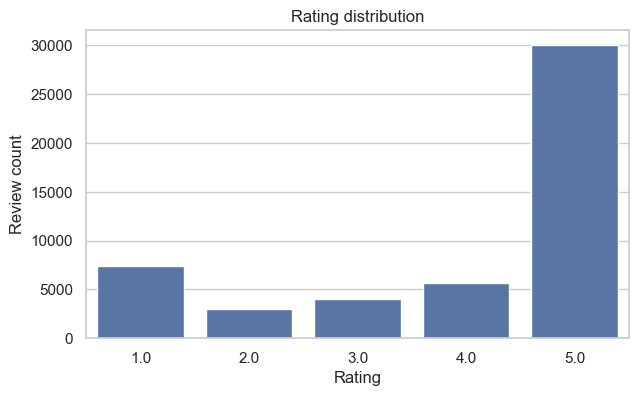

,rating_num
count,50000.000000
mean,3.960720
std,1.497445
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


sentiment_label
positive    71.4
negative    20.7
neutral      7.9
Name: proportion, dtype: float64

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=review_level, x="rating_num", ax=ax)
ax.set_title("Rating distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Review count")
plt.show()

rating_summary = review_level["rating_num"].describe().to_frame("rating_num")
display(rating_summary)

sentiment_share = review_level["sentiment_label"].value_counts(normalize=True).mul(100).round(1)
display(sentiment_share)


## 10. EDA: Rating Imbalance and Baseline

Rating imbalance pitfall avoided: later model evaluation should report macro-F1 or class-balanced metrics, not accuracy alone. A simple majority-class baseline is saved before any deep model work.


In [17]:
class_balance = review_level.groupby("sentiment_label", observed=False).size().reset_index(name="reviews")
class_balance["share_pct"] = (class_balance["reviews"] / class_balance["reviews"].sum() * 100).round(1)
display(class_balance)

majority_label = train_df["sentiment_label"].mode()[0]
baseline_rows = []
for split_name, eval_df in [("val", val_df), ("test", test_df)]:
    y_true = eval_df["sentiment_label"].astype(str)
    y_pred = pd.Series([str(majority_label)] * len(eval_df), index=eval_df.index)
    baseline_rows.append({
        "model": "majority_class_baseline",
        "split": split_name,
        "majority_label": str(majority_label),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    })

baseline_metrics = pd.DataFrame(baseline_rows)
baseline_metrics.to_csv(BASELINE_METRICS_PATH, index=False)
display(baseline_metrics.round(4))


,sentiment_label,reviews,share_pct
0,negative,10347,20.7
1,neutral,3966,7.9
2,positive,35687,71.4


,model,split,majority_label,accuracy,macro_f1
0,majority_class_baseline,val,positive,0.7073,0.2762
1,majority_class_baseline,test,positive,0.7191,0.2789


## 11. EDA: Price Distribution

Uses the cleaned numeric `price_num` field. The log-scale histogram is useful because product prices are often skewed.


,count,mean,median,min,max,missing_pct
0,17704,27.26,16.99,0.01,2548.98,84.28


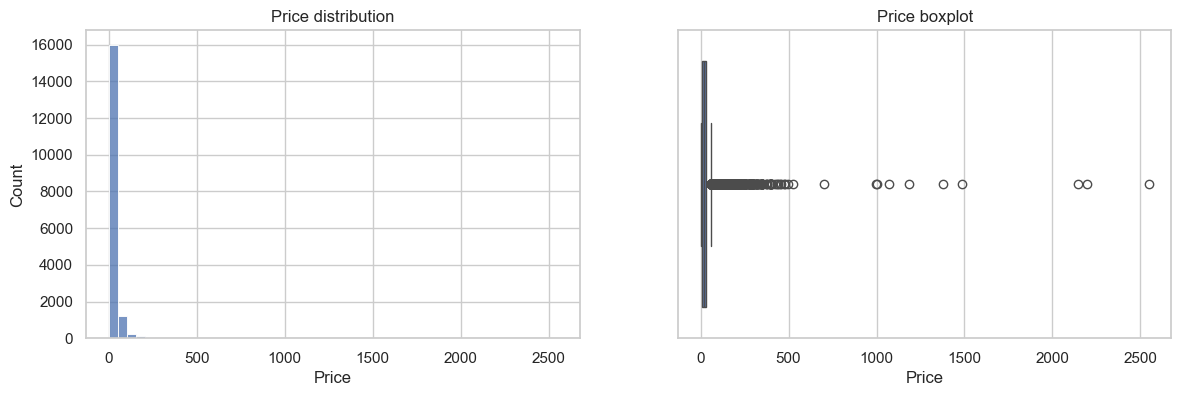

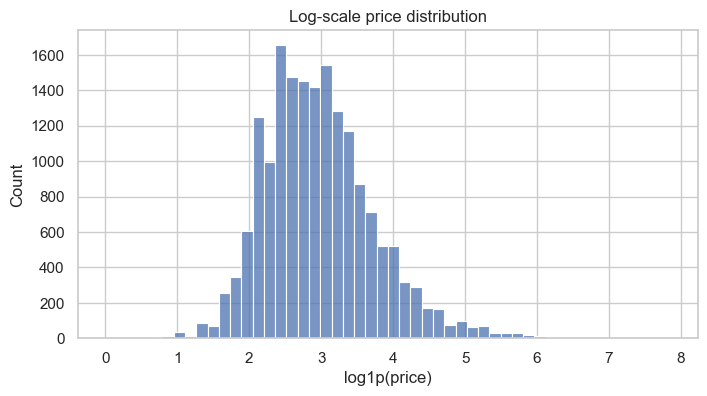

In [18]:
if "price_num" not in review_level.columns:
    price_col = first_existing_column(review_level, PRICE_COLUMN_CANDIDATES)
    review_level["price_num"] = review_level[price_col].map(clean_price).pipe(pd.to_numeric, errors="coerce") if price_col else pd.NA

price_series = pd.to_numeric(product_level["price_num"], errors="coerce") if "price_num" in product_level.columns else pd.Series(dtype="float")
price_stats = pd.DataFrame({
    "count": [int(price_series.notna().sum())],
    "mean": [price_series.mean()],
    "median": [price_series.median()],
    "min": [price_series.min()],
    "max": [price_series.max()],
    "missing_pct": [round(float(price_series.isna().mean() * 100), 2) if len(price_series) else np.nan],
})
display(price_stats.round(2))

plot_prices = price_series.dropna()
plot_prices = plot_prices[plot_prices > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(plot_prices, bins=50, ax=axes[0])
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price")

sns.boxplot(x=plot_prices, ax=axes[1])
axes[1].set_title("Price boxplot")
axes[1].set_xlabel("Price")
plt.show()

if len(plot_prices):
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(np.log1p(plot_prices), bins=50, ax=ax)
    ax.set_title("Log-scale price distribution")
    ax.set_xlabel("log1p(price)")
    plt.show()


## 12. EDA: Review Length Distribution


,review_length
count,50000.000000
mean,33.497000
std,46.429375
min,0.000000
25%,8.000000
50%,20.000000
75%,41.000000
max,1211.000000


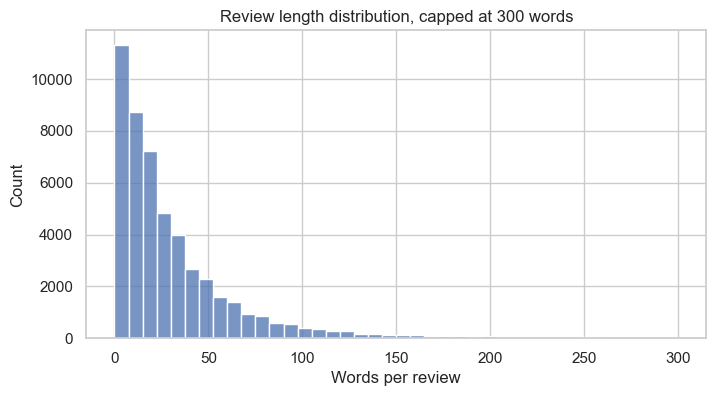

In [19]:
review_length_stats = review_level["review_length"].describe().to_frame("review_length")
display(review_length_stats)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(review_level.query("review_length <= 300"), x="review_length", bins=40, ax=ax)
ax.set_title("Review length distribution, capped at 300 words")
ax.set_xlabel("Words per review")
plt.show()


## 13. EDA: Image Availability


,level,rows,with_image_url,with_cached_image,image_url_pct,cached_image_pct
0,metadata_products,112590,112590,300,100.0,0.27
1,review_rows,50000,50000,217,100.0,0.43


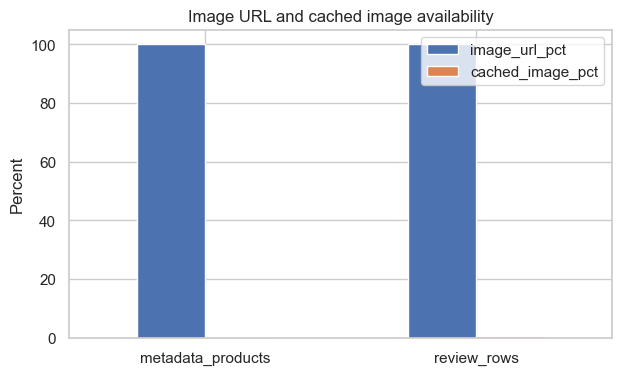

In [20]:
image_availability = pd.DataFrame({
    "level": ["metadata_products", "review_rows"],
    "rows": [len(metadata), len(review_level)],
    "with_image_url": [
        int(metadata["primary_image_url"].notna().sum()),
        int(review_level["primary_image_url"].notna().sum()),
    ],
    "with_cached_image": [
        int(metadata["cached_image_path"].fillna("").ne("").sum()),
        int(review_level["cached_image_path"].fillna("").ne("").sum()),
    ],
})
image_availability["image_url_pct"] = (image_availability["with_image_url"] / image_availability["rows"] * 100).round(2)
image_availability["cached_image_pct"] = (image_availability["with_cached_image"] / image_availability["rows"] * 100).round(2)
display(image_availability)

fig, ax = plt.subplots(figsize=(7, 4))
image_availability.set_index("level")[["image_url_pct", "cached_image_pct"]].plot(kind="bar", ax=ax)
ax.set_title("Image URL and cached image availability")
ax.set_ylabel("Percent")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()


## 14. EDA: Time Trend and Product View


,review_year,reviews,avg_rating
6,2009,75,4.120000
7,2010,109,4.192661
8,2011,132,4.015152
9,2012,191,4.141361
10,2013,562,4.154804
11,2014,1179,4.195929
12,2015,2597,4.186754
13,2016,4482,4.091031
14,2017,4832,4.001242
15,2018,5184,3.967785


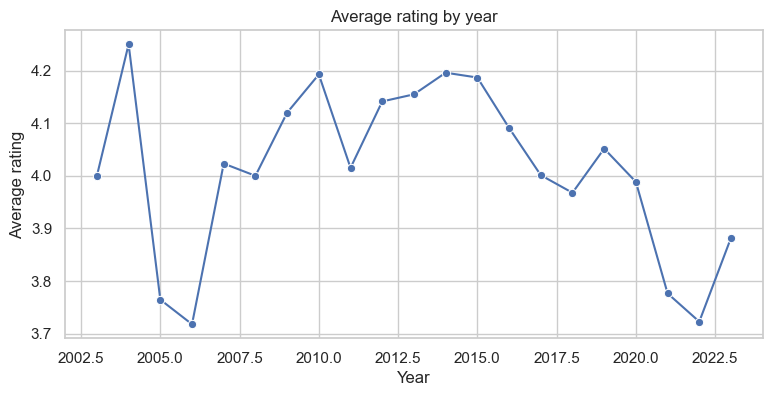

In [21]:
if "review_year" in review_level.columns:
    yearly = review_level.groupby("review_year").agg(
        reviews=("rating_num", "size"),
        avg_rating=("rating_num", "mean"),
    ).reset_index()
    display(yearly.tail(15))

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.lineplot(data=yearly, x="review_year", y="avg_rating", marker="o", ax=ax)
    ax.set_title("Average rating by year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Average rating")
    plt.show()


,product_id,product_title,store_name,price_num,average_rating,rating_number,primary_image_url,cached_image_path,image_cache_status,main_category_clean,review_count,review_rating_mean,review_rating_median,negative_review_count,positive_review_count
8268,B078JFH7QV,L7 MANNEQUIN Realistic Mannequin Head with Shoulders Plastic mannequin Heads for Wigs Earrings Hat Sunglassess Display,L7 MANNEQUIN,59.97,4.8,1028,https://m.media-amazon.com/images/I/41-1WfBS8iL._SL1001_.jpg,NaN,NaN,All Beauty,16,5.0,5.0,0,16
33374,B00AJOJ0GW,Corn Huskers Lotion 7 oz ( Pack of 4),Johnson & Johnson,20.07,4.9,1027,https://m.media-amazon.com/images/I/71Zh4o0-cyL._SL1500_.jpg,NaN,NaN,All Beauty,15,5.0,5.0,0,15
77705,B07MC84KMN,"QtGirl Hair Bow Holder Organizer for Girls, Unicorn Bow Hanger Hair Clips Storage Hair Accessories Headband Storage ...",QtGirl,NaN,4.8,874,https://m.media-amazon.com/images/I/51z7Rfs01UL._SL1001_.jpg,NaN,NaN,All Beauty,14,5.0,5.0,0,14
2776,B07N38K4RW,JIMIRE 20 Pairs False Eyelashes Natural Short Lashes Pack Bulk Eyelashes Multipack,JIMIRE,NaN,4.2,321,https://m.media-amazon.com/images/I/81FZWHCLz+L._SL1500_.jpg,NaN,NaN,All Beauty,13,5.0,5.0,0,13
10181,B0C3LVTX2V,ANOGOL Free Cap + Purple Mix Pink Cosplay Wig with Ponytail for Cosplay Costume Party Halloween,ANOGOL,19.98,4.3,1067,https://m.media-amazon.com/images/I/71tdgC+h76L._SL1000_.jpg,NaN,NaN,All Beauty,11,5.0,5.0,0,11
6134,B00IG0677G,OCuSOFT Plus Eyelid Cleanser Pads 30 Each (Pack of 3),OCuSOFT,29.85,4.8,800,https://m.media-amazon.com/images/I/71U3-V8UeJL._SL1500_.jpg,NaN,NaN,All Beauty,10,5.0,5.0,0,10
26549,B09GS65Y1T,"Purpose Gentle Cleansing Wash, 6 oz (Pack of 2)",With a Purpose,16.25,4.8,1540,https://m.media-amazon.com/images/I/616R781dkQL._SL1500_.jpg,NaN,NaN,All Beauty,10,5.0,5.0,0,10
79903,B08NFJ2GGT,Nopunzel Hair Inhibitor- 20 ML - Hair Stop Growth Spray - Natural Ingredient to Inhibit and Reduce to Stop Hair Grow...,Nopunzel,12.99,3.2,315,https://m.media-amazon.com/images/I/71Bm-vyOo-S._SL1500_.jpg,NaN,NaN,All Beauty,10,5.0,5.0,0,10
10168,B07RQYT93N,"Jibitee Replacement Brush Heads Compatible with Philips Sonicare E-Series HX7022/66, fit Screw-On Electric Toothbrus...",Jibitee,19.99,4.7,1265,https://m.media-amazon.com/images/I/41pnx3jv6VL.jpg,NaN,NaN,All Beauty,9,5.0,5.0,0,9
17156,B005X5SHJS,US Acrylic Large Clear Plastic Makeup Organizer with Removable Compartment | Signature Collection,US Acrylic,NaN,4.3,162,https://m.media-amazon.com/images/I/61xaW2N+yEL._SL1000_.jpg,NaN,NaN,All Beauty,9,5.0,5.0,0,9


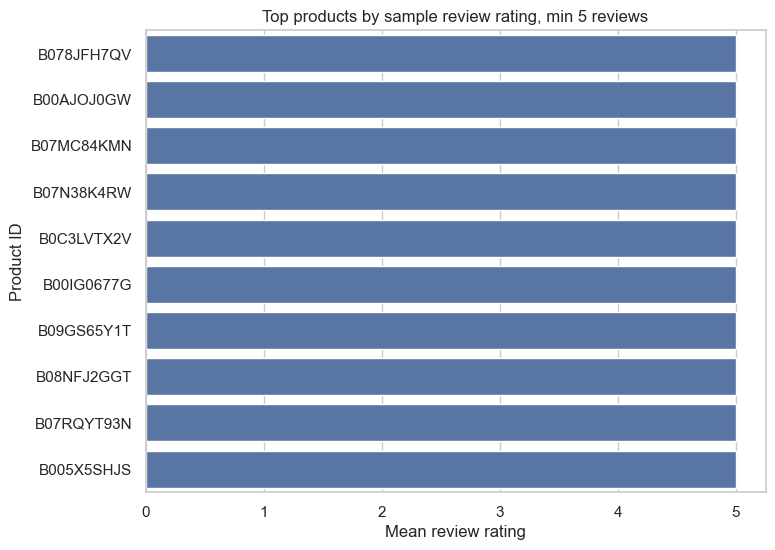

In [22]:
top_products = (
    product_level.query("review_count >= 5")
    .sort_values(["review_rating_mean", "review_count"], ascending=[False, False])
    .head(20)
)
display(top_products)

if not top_products.empty:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=top_products.head(10), y="product_id", x="review_rating_mean", ax=ax)
    ax.set_title("Top products by sample review rating, min 5 reviews")
    ax.set_xlabel("Mean review rating")
    ax.set_ylabel("Product ID")
    plt.show()


## 15. Negative Review Examples

Use this table to identify recurring customer pain points for the next milestone.


In [23]:
negative_columns = [
    column
    for column in ["product_id", "product_title", "rating_num", "review_date", "review_text"]
    if column in review_level.columns
]

display(review_level.query("rating_num <= 2")[negative_columns].head(25))


,product_id,product_title,rating_num,review_date,review_text
3,B01DX9HUP2,Buytra 20-Piece Makeup Brushes Makeup Brush Set Cosmetics Foundation Blending Blush Eyeliner Concealer Face Powder B...,1.0,2017-06-15 21:07:17.278,Just not worth it
5,B01JYIC6O6,DATEWORK 15 Colors Cosmetic Makeup Neutral Nudes Warm Eyeshadow Palette,1.0,2016-09-17 01:18:25.000,When it came to me one of the shadows was broken. Powder was everywhere on all of the shadows for the price it is ok...
7,B07WVBDLG9,7Rainbows 10pcs Girls Unicorn Hair Bows On Headband Pineapple Hair Hoop Princess Dance Headbands.,2.0,2020-12-06 16:14:33.006,They look nice but do not stay on. They have no teeth and aren’t tight/strong enough.
11,B00Y3DF9X8,Blue Donuts Disposable Shower Caps 100 Pieces Clear Plastic Shower Hair Caps,2.0,2017-01-01 11:04:57.000,They are very very small. You definitely have to stretch them out to fit a normal size head. So if you have a larger...
21,B01195J43I,DASKY 29W Digital Anti Static Ceramic Hair Straightener Heating Detangling Hair Brush Paddle Brush For Faster Straig...,1.0,2016-05-16 11:13:11.000,Brooke easy
23,B01LBESKBO,Cosmetic Art 30-Piece Nail Polish Color Lacquer Set,1.0,2018-11-23 23:04:45.354,They were broken! And no option to replace or return since it's flammable. I want a refund!
25,B07NYS5DNQ,Chew Sticks - Various Flavors - 1 Lb. (Vanilla),1.0,2022-04-30 17:51:06.792,Not for me
28,B07W39SF2Z,"Aksice Wig Grip, Flexible Velvet No Slip Wig Grip Band, Wig Grip Headbands for Women, Wig Band Grip to Keep Wig Secu...",1.0,2021-04-22 21:47:58.510,Not worth the price. Doesn't last long. Slips when you sweat
32,B0B58R52CT,"Diduikalor Press On Nails Short Square Oval, Flower Pearl Acrylic False Nails for Women Girls, Trendy Luxury Charms ...",2.0,2022-09-27 00:04:40.548,"Kept falling as soon as I stick them on, the back of the nails is not sticking to the stickers so they kept falling..."
33,B0B23TGQWC,"Skin Tone Adjusting CC Cream, Cosmetics CC Cream, Skin Tone Adjusting CC Cream SPF 50, Colour Correcting Self Adjust...",1.0,2022-08-08 17:25:08.733,The product goes in very thick and just sits on your skin!


## 16. Common Pitfalls Checked

- Broken image links: product images are cached during Milestone 0 and referenced through `cached_image_path`.
- Data leakage: train/val/test split is by `product_id`, with explicit zero-overlap checks.
- Rating imbalance: class balance and a majority-class baseline are reported; later models should use macro-F1/class-balanced metrics.
- Skipping baselines: a simple baseline is saved before deep model work.
- Over-scoping generation: use inference-ready models; training large models from scratch is out of scope.
- Integration risk: later milestones should consume these frozen artifacts instead of introducing a new data pipeline at the end.


## 17. Dynamic Milestone 0 Summary

This cell prints the final status from the actual dataframes and saved paths. No hard-coded summary counts are used.


In [24]:
output_paths = {
    "review_level": REVIEW_LEVEL_PATH,
    "product_level": PRODUCT_LEVEL_PATH,
    "train": TRAIN_PATH,
    "val": VAL_PATH,
    "test": TEST_PATH,
    "missing_data_report": MISSING_REPORT_PATH,
    "image_manifest": IMAGE_MANIFEST_PATH,
    "baseline_metrics": BASELINE_METRICS_PATH,
}

split_counts = split_df.groupby("split").agg(
    review_count=("product_id", "size"),
    product_count=("product_id", "nunique"),
).reindex(["train", "val", "test"])

image_availability_pct = round(float(review_level["cached_image_path"].fillna("").ne("").mean() * 100), 2)

summary = {
    "selected_category": CATEGORY,
    "current_image_cache_limit": MAX_IMAGES_TO_CACHE,
    "full_cv_image_cache_target": FULL_IMAGE_CACHE_TARGET,
    "reviews": len(review_level),
    "unique_products_in_reviews": review_level["product_id"].nunique(),
    "metadata_rows": len(raw_metadata),
    "train_review_count": int(split_counts.loc["train", "review_count"]),
    "val_review_count": int(split_counts.loc["val", "review_count"]),
    "test_review_count": int(split_counts.loc["test", "review_count"]),
    "train_product_count": int(split_counts.loc["train", "product_count"]),
    "val_product_count": int(split_counts.loc["val", "product_count"]),
    "test_product_count": int(split_counts.loc["test", "product_count"]),
    "leakage_check": "PASS" if leakage_pass else "FAIL",
    "attempted_image_downloads_or_cache_checks": image_download_attempts,
    "successful_cached_images": successful_cached_images,
    "image_availability_pct_review_rows": image_availability_pct,
    "missing_data_report_path": str(MISSING_REPORT_PATH.relative_to(PROJECT_ROOT)),
    "cached_image_directory_path": str(IMAGE_CACHE_DIR.relative_to(PROJECT_ROOT)),
}

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))

print("Saved output paths:")
for name, path in output_paths.items():
    print(f"- {name}: {path.relative_to(PROJECT_ROOT)}")


,value
selected_category,All_Beauty
current_image_cache_limit,300
full_cv_image_cache_target,5000
reviews,50000
unique_products_in_reviews,25371
metadata_rows,112590
train_review_count,34891
val_review_count,7721
test_review_count,7388
train_product_count,17759


Saved output paths:
- review_level: data/processed/review_level.parquet
- product_level: data/processed/product_level.parquet
- train: data/processed/train.parquet
- val: data/processed/val.parquet
- test: data/processed/test.parquet
- missing_data_report: data/processed/missing_data_report.csv
- image_manifest: data/processed/all_beauty_image_manifest.csv
- baseline_metrics: data/processed/baseline_majority_sentiment_metrics.csv
